# Phase 2: Unsupervised Learning for Initial Detection (Anomaly-Based IDS)
# Task 2.1: Packet-Level Anomaly Detection
# K-Means

Build an unsupervised model that separates benign from non-benign packets.

## Setup, load metadata and sampled packet dataset

In [ ]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    silhouette_score
)

METADATA_FILE_NAME = "packet_sample_seed1.metadata.json"

## load packet dataset and metadata
PROJECT_ROOT = Path("..")
META_PATH = PROJECT_ROOT / "data" / "samples" / METADATA_FILE_NAME
with open(META_PATH, "r") as f:
    metadata = json.load(f)
metadata
DATA_PATH = PROJECT_ROOT / metadata["output_path"]
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

## check class imbalance
BINARY_COL = "binary_label"
ATTACK_COL = "attack_type"
print(df[BINARY_COL].value_counts())
print()
print(df[ATTACK_COL].value_counts())

## Create numeric labels for evaluation only
y_true = df[BINARY_COL].map({
    "benign": 0,
    "attack": 1
}).to_numpy()

(205041, 138)
binary_label
benign    200000
attack      5041
Name: count, dtype: int64

attack_type
Benign             200000
DNS Spoofing         3178
DDoS-HTTP Flood       833
Brute Force           404
DoS-HTTP Flood        364
XSS                   262
Name: count, dtype: int64


## K-Means

### K-Means Data feature selections:

K-Means is distance-based, so numeric feature scaling is required.<br>
Text fields such as IP addresses, MAC addresses, host names, and user agents should not be directly used.<br>
These labels are removed before training to avoid leakage.<br>

In [159]:
# Basic packet-level features
base_features = [
    "time_since_previously_displayed_frame",
    "l4_tcp",
    "l4_udp",
    "ttl",
    "eth_size",
    "tcp_window_size",
    "payload_entropy",
    "jitter",
    "dns_len_qry",
    "dns_interval",
    "dns_len_ans",
    "http_content_len",
    "handshake_cipher_suites_length",
    "handshake_extensions_length",
    "handshake_sig_hash_alg_len",
    "l3_ip_dst_count"
]

# Use one rolling window to reduce redundancy
window_features = [
    "stream_5_count",
    "stream_5_mean",
    "stream_5_var",

    "src_ip_5_count",
    "src_ip_5_mean",
    "src_ip_5_var",

    "channel_5_count",
    "channel_5_mean",

    "stream_jitter_5_mean",
    "stream_jitter_5_var"
]

feature_cols = base_features + window_features

missing_features = [
    col for col in feature_cols
    if col not in df.columns
]

feature_cols = [
    col for col in feature_cols
    if col in df.columns
]

X_raw = df[feature_cols].copy()

# Replace the highly correlated payload_length feature
# with the payload proportion
packet_size = df["eth_size"].replace(0, np.nan)

X_raw["payload_ratio"] = (
    df["payload_length"] / packet_size
).fillna(0)

# Compare short-term activity with longer-term activity
def burst_ratio(short_col, long_col):
    short_count = pd.to_numeric(
        df[short_col],
        errors="coerce"
    ).fillna(0)

    long_count = pd.to_numeric(
        df[long_col],
        errors="coerce"
    ).fillna(0)

    # Activity during the most recent 5 units
    recent_rate = short_count / 5

    # Activity during the earlier 25 units
    previous_count = (long_count - short_count).clip(lower=0)
    previous_rate = previous_count / 25

    # Smoothing prevents division by zero
    return (recent_rate + 1) / (previous_rate + 1)


X_raw["stream_burst_ratio"] = burst_ratio(
    "stream_5_count",
    "stream_30_count"
)

X_raw["src_ip_burst_ratio"] = burst_ratio(
    "src_ip_5_count",
    "src_ip_30_count"
)

X_raw["channel_burst_ratio"] = burst_ratio(
    "channel_5_count",
    "channel_30_count"
)

burst_features = [
    "stream_burst_ratio",
    "src_ip_burst_ratio",
    "channel_burst_ratio"
]
print("\nBurst feature summary:")
print(X_raw[burst_features].describe())

print("Selected features:", X_raw.shape[1])
print("Missing requested features:", missing_features)

X_raw.head()


Burst feature summary:
       stream_burst_ratio  src_ip_burst_ratio  channel_burst_ratio
count       205041.000000       205041.000000        205041.000000
mean             3.347580            3.996210            10.869717
std             10.158807           22.913010            72.265694
min              0.020202            0.009728             0.076531
25%              1.129032            1.000000             1.005917
50%              1.400000            1.094675             1.116208
75%              2.193878            1.351351             1.486486
max            225.800000          867.500000           969.000000
Selected features: 30
Missing requested features: []


,time_since_previously_displayed_frame,l4_tcp,l4_udp,ttl,eth_size,tcp_window_size,payload_entropy,jitter,dns_len_qry,dns_interval,...,src_ip_5_mean,src_ip_5_var,channel_5_count,channel_5_mean,stream_jitter_5_mean,stream_jitter_5_var,payload_ratio,stream_burst_ratio,src_ip_burst_ratio,channel_burst_ratio
0,0.000185,1,0,64,60,0,0.000000,0.000185,0,0.0,...,117.428571,14842.041667,14.0,347.928571,75.288689,79105.166968,0.000000,3.800000,1.179039,3.800000
1,0.000290,1,0,49,66,65024,0.000000,0.000290,0,0.0,...,102.424242,11834.001894,65.0,105.861538,265.693714,635068.703264,0.000000,2.800000,1.085714,1.051051
2,0.003855,1,0,64,74,14600,0.000000,947.623914,0,0.0,...,104.813953,6684.535991,66.0,108.348485,947.623914,NaN,0.000000,1.200000,1.081081,1.072508
3,0.003104,0,1,64,60,0,3.201876,0.005255,0,0.0,...,88.576923,20528.013846,47.0,82.255319,0.305904,2.285203,0.266667,2.777778,1.371681,2.826087
4,0.000001,1,0,231,66,4415,0.000000,0.000001,0,0.0,...,66.000000,0.000000,354.0,1081.618644,0.015520,0.004361,0.000000,1.429706,1.451327,1.429140


### K-Means Basic preprocessing

Need to:<br>
&emsp;replace inf values<br>
&emsp;impute missing values with median<br>
&emsp;scale features<br>
&emsp;remove constant columns<br>

Missing and infinite values were replaced using median imputation because packet-level network features may contain undefined variance, jitter, or rate values. Constant columns were removed because they do not help clustering. Standard scaling was applied because K-Means uses Euclidean distance, and unscaled large-magnitude features would dominate the cluster assignment.

In [160]:
X_clean = X_raw.replace([np.inf, -np.inf], np.nan).copy()

missing_rate = (
    X_clean.isna()
    .mean()
    .loc[lambda values: values > 0]
    .sort_values(ascending=False)
)

print("Missing-value rates:")
print(missing_rate)

# Missing variance or jitter usually means there were
# not enough previous packets to calculate the value
zero_fill_cols = [
    col for col in X_clean.columns
    if col.endswith("_var") or "jitter" in col
]

X_clean[zero_fill_cols] = X_clean[zero_fill_cols].fillna(0)

# Remove empty and constant columns
X_clean = X_clean.dropna(axis=1, how="all")

constant_cols = X_clean.columns[
    X_clean.nunique(dropna=True) <= 1
]

X_clean = X_clean.drop(columns=constant_cols)

# Log-transform strongly right-skewed features
log_cols = []

for col in X_clean.columns:
    values = X_clean[col].dropna()

    if (
        len(values) > 0
        and values.min() >= 0
        and abs(values.skew()) > 2
    ):
        log_cols.append(col)

X_clean[log_cols] = np.log1p(X_clean[log_cols])

preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X = preprocess.fit_transform(X_clean)

print("\nOriginal features:", X_raw.shape[1])
print("Log-transformed features:", len(log_cols))
print("Final processed shape:", X.shape)

Missing-value rates:
stream_jitter_5_var     0.214440
src_ip_5_var            0.175521
stream_5_var            0.165889
src_ip_5_count          0.064885
src_ip_5_mean           0.064885
jitter                  0.051687
stream_jitter_5_mean    0.051687
dtype: float64

Original features: 30
Log-transformed features: 25
Final processed shape: (205041, 30)


### Tune K-Means hyperparameter k

Using inertia and silhouette score<br>
Because silhouette score is expensive on 205k rows, calculate it on a smaller random subset.<br>
Use Elbow method<br>

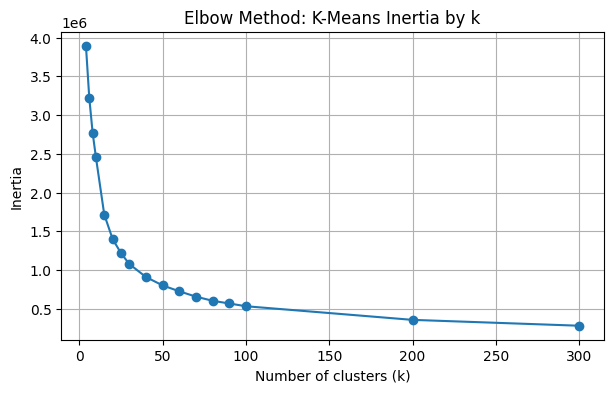

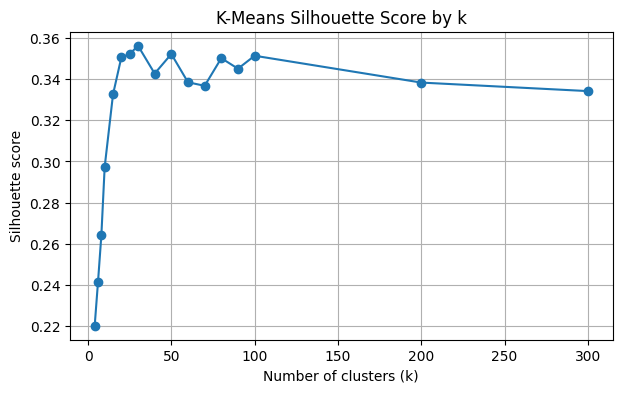

In [210]:
## tododo: use elbow method
k_values = [4, 6, 8, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300]
# k_values = range(2, 15)
tuning_results = []

## use random subset to save time
rng = np.random.default_rng(1)
sample_idx = rng.choice(X.shape[0], size=min(20000, X.shape[0]), replace=False)
X_sil = X[sample_idx]

for k in k_values:
    start = time.time()
    
    model = KMeans(
        n_clusters=k,
        random_state=1,
        n_init=10
    )
    labels = model.fit_predict(X)
    
    sil = silhouette_score(X_sil, labels[sample_idx])
    # sil = silhouette_score(X, labels) # use full data
    runtime = time.time() - start
    
    tuning_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette_sample": sil,
        "runtime_sec": runtime
    })

kmeans_tuning_df = pd.DataFrame(tuning_results)
kmeans_tuning_df

plt.figure(figsize=(7, 4))
plt.plot(kmeans_tuning_df["k"], kmeans_tuning_df["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method: K-Means Inertia by k")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(kmeans_tuning_df["k"], kmeans_tuning_df["silhouette_sample"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("K-Means Silhouette Score by k")
plt.grid(True)
plt.show()

For K-Means, the main hyperparameter I tuned is the number of clusters, k. Since this is an unsupervised model, I did not use the packet labels when choosing k. Instead, I compared different k values using two clustering-based measures: inertia and silhouette score.<br>

Inertia measures how close the data points are to their assigned cluster centers. A lower inertia usually means the clusters are more compact, but inertia will almost always decrease as k increases, so I used it mainly to look for an “elbow” point where the improvement starts to slow down.<br>

The silhouette score measures how well-separated the clusters are. A higher silhouette score means the clusters are more clearly separated. From the plot, the silhouette score is highest around k = 20 to k = 100. This suggests that using too few clusters may split the data into less meaningful groups.<br>

<!-- Based on both plots, I would choose **k = 4** as a reasonable starting value. It still has a high silhouette score, and the inertia has already improved compared with k = 2 and k = 3. I will use this value as the initial K-Means setting, then evaluate the anomaly detection performance using precision, recall, F1-score, FPR, FNR, AUC-ROC, and per-attack detection rate.<br> -->

I compared different values of k using inertia and silhouette score. These measures describe cluster compactness and separation, but they do not directly measure anomaly-detection performance. Smaller values such as k = 20 produced weaker detection results in later experiments, while k = 50 gave better ROC-AUC and F1-score with the current feature representation. Therefore, k = 50 is retained as the current baseline. Packet labels are not used when fitting K-Means and are used only afterward for evaluation.<br>

### Train K-Means model

In [211]:
BEST_K = 50

start_train = time.time()

kmeans = KMeans(
    n_clusters=BEST_K,
    random_state=1,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X)

train_time = time.time() - start_train

cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()

print("Training time:", train_time)
print("\nCluster sizes:")
print(cluster_sizes)

print("\nCluster size summary:")
print(cluster_sizes.describe())


### cluster mapping
df_clusters = df.copy()
df_clusters["cluster"] = cluster_labels
cluster_mapping = (
    df_clusters
    .groupby("cluster")["attack_type"]
    .value_counts()
    .groupby(level=0)
    .head(5)
)
print("\nCluster composition:")
print(cluster_mapping)

Training time: 6.059168100357056

Cluster sizes:
0      6384
1      3234
2     28754
3      6632
4      2282
5      2394
6      9962
7      1341
8       551
9      6568
10     5334
11     2009
12     2027
13     3889
14     3960
15     7310
16     5160
17     3205
18     2719
19      384
20     1748
21     5159
22     3463
23     1286
24     4434
25     9643
26     6721
27     3645
28     3984
29     2716
30     5306
31      930
32     2794
33     3576
34     1930
35     4364
36     3479
37     6617
38     3809
39     2719
40     3998
41     3335
42     1069
43     1102
44     1657
45     1771
46     4338
47      663
48     3466
49     1220
Name: count, dtype: int64

Cluster size summary:
count       50.000000
mean      4100.820000
std       4184.029791
min        384.000000
25%       1949.750000
50%       3464.500000
75%       4977.750000
max      28754.000000
Name: count, dtype: float64

Cluster composition:
cluster  attack_type   
0        Benign            6361
         DNS Spoofin

## Evaluation

### Phase 2 evaluation metrics

The project requires Phase 2 packet-level evaluation with precision, recall, F1-score, per-attack detection rate, FPR, FNR, AUC-ROC, and a confusion matrix. The function below keeps the output as one simple table so it can be compared with the K-Means results later.

In [212]:
### Generate anomaly scores (distance from a packet to its nearest cluster center)
# distances = kmeans.transform(X)
# anomaly_score = distances.min(axis=1)

# Distance from each packet to its assigned cluster center
distances = kmeans.transform(X)
anomaly_score = distances[np.arange(X.shape[0]), cluster_labels]

df_result = df.copy()
df_result["model"] = "KMeans"
df_result["cluster"] = cluster_labels
df_result["anomaly_score"] = anomaly_score
df_result[["cluster", "anomaly_score", BINARY_COL, ATTACK_COL]].head()

,cluster,anomaly_score,binary_label,attack_type
0,18,2.837429,benign,Benign
1,2,0.719251,benign,Benign
2,10,0.416121,benign,Benign
3,15,1.750568,benign,Benign
4,29,1.378132,benign,Benign


### Threshold sensitivity analysis

The threshold controls the false-positive and false-negative trade-off. A lower alert rate usually reduces false positives but may miss more attacks. A higher alert rate usually catches more attacks but creates more false alarms. The table below tests a few alert rates around the project attack proportion. Labels are used here only for evaluation and analysis, not for model training.

In [213]:
### Pick alert threshold
expected_attack_rate = metadata["total_attack_rows"] / metadata["total_rows"]
# threshold = np.quantile(anomaly_score, 1 - expected_attack_rate)
# df_result["y_pred"] = (df_result["anomaly_score"] >= threshold).astype(int)

### threshold sensitivity analysis, different attack rate
alert_rates = [
    0.01,
    0.015,
    0.02,
    expected_attack_rate,
    0.03,
    0.04,
    0.05
]
threshold_results = []
for alert_rate in alert_rates:
    current_threshold = np.quantile(anomaly_score, 1 - alert_rate)

    current_pred = (anomaly_score >= current_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, current_pred).ravel()

    threshold_results.append({
        "alert_rate": alert_rate,
        "threshold": current_threshold,
        "alerts": current_pred.sum(),
        "precision": precision_score(
            y_true,
            current_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            current_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            current_pred,
            zero_division=0
        ),
        "fpr": fp / (fp + tn),
        "fnr": fn / (fn + tp)
    })
threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

threshold = np.quantile(anomaly_score, 1 - expected_attack_rate)
df_result["y_pred"] = (anomaly_score >= threshold).astype(int)
print("Expected alert rate:", expected_attack_rate)
print("Threshold:", threshold)
print(df_result["y_pred"].value_counts())
print("--------------------")

,alert_rate,threshold,alerts,precision,recall,f1,fpr,fnr
0,0.010000,4.697407,2051,0.488542,0.198770,0.282572,0.005245,0.801230
1,0.015000,4.370453,3076,0.421326,0.257092,0.319330,0.008900,0.742908
2,0.020000,4.175314,4101,0.360644,0.293394,0.323562,0.013110,0.706606
3,0.024585,4.046548,5041,0.326126,0.326126,0.326126,0.016985,0.673874
4,0.030000,3.919344,6152,0.285273,0.348145,0.313589,0.021985,0.651855
5,0.040000,3.701859,8202,0.240795,0.391787,0.298271,0.031135,0.608213
6,0.050000,3.520867,10253,0.218668,0.444753,0.293187,0.040055,0.555247


Expected alert rate: 0.02458532683707161
Threshold: 4.046548129318066
y_pred
0    200000
1      5041
Name: count, dtype: int64
--------------------


In [214]:
# Selected from the threshold sensitivity analysis
FINAL_ALERT_RATE = 0.02
threshold = np.quantile(anomaly_score, 1 - FINAL_ALERT_RATE)
df_result["y_pred"] = (anomaly_score >= threshold).astype(int)

print("Selected alert rate:", FINAL_ALERT_RATE)
print("Threshold:", threshold)
print(df_result["y_pred"].value_counts())

## Phase 2 metrics
def evaluate_phase2_detection(y_true, y_pred, scores, attack_types, model_name, runtime_sec):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    auc_roc = roc_auc_score(y_true, scores)
    pr_auc = average_precision_score(y_true, scores)

    benign_count = (y_true == 0).sum()
    attack_count = (y_true == 1).sum()
    attack_rate = attack_count / len(y_true)

    result = {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fpr": fpr,
        "fnr": fnr,
        "auc_roc": auc_roc,
        "pr_auc": pr_auc,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "benign_count": benign_count,
        "attack_count": attack_count,
        "attack_rate": attack_rate,
        "runtime_sec": runtime_sec
    }

    # Per-attack detection rate
    attack_names = ["DDoS-HTTP Flood", "DoS-HTTP Flood", "DNS Spoofing", "Brute Force", "XSS"]

    for attack in attack_names:
        attack_mask = attack_types == attack

        if attack_mask.sum() > 0:
            detection_rate = y_pred[attack_mask].mean()
        else:
            detection_rate = 0

        col_name = attack.lower().replace(" ", "_").replace("-", "_") + "_detect_rate"
        result[col_name] = detection_rate

    return result

metrics = evaluate_phase2_detection(
    y_true=y_true,
    y_pred=df_result["y_pred"].to_numpy(),
    scores=df_result["anomaly_score"].to_numpy(),
    attack_types=df_result[ATTACK_COL].to_numpy(),
    model_name="KMeans",
    runtime_sec=train_time
)

metrics_df = pd.DataFrame([metrics])
display(metrics_df)

Selected alert rate: 0.02
Threshold: 4.175313522466753
y_pred
0    200940
1      4101
Name: count, dtype: int64


,model,accuracy,precision,recall,f1,fpr,fnr,auc_roc,pr_auc,tp,...,fn,benign_count,attack_count,attack_rate,runtime_sec,ddos_http_flood_detect_rate,dos_http_flood_detect_rate,dns_spoofing_detect_rate,brute_force_detect_rate,xss_detect_rate
0,KMeans,0.96984,0.360644,0.293394,0.323562,0.01311,0.706606,0.843733,0.243482,1479,...,3562,200000,5041,0.024585,6.059168,0.7491,0.563187,0.18691,0.10396,0.053435


#### Confusion matrix visualization

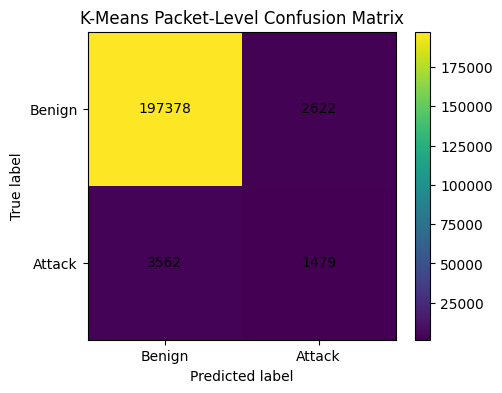

In [215]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    
    classes = ["Benign", "Attack"]
    plt.xticks([0, 1], classes)
    plt.yticks([0, 1], classes)
    
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.show()

plot_confusion_matrix(
    y_true,
    df_result["y_pred"].to_numpy(),
    "K-Means Packet-Level Confusion Matrix"
)

#### ROC curve

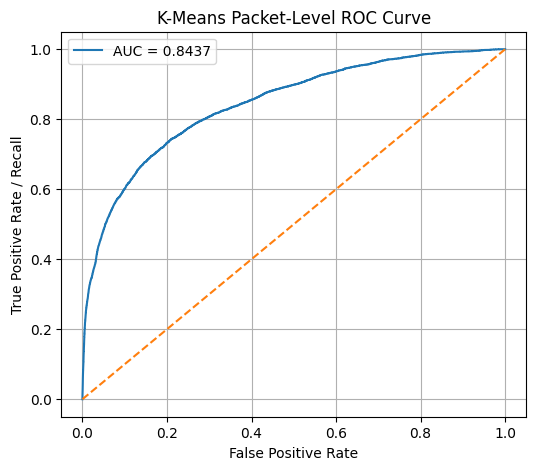

In [216]:
def plot_roc_curve(y_true, scores, title):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    auc_value = roc_auc_score(y_true, scores)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_value:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate / Recall")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_roc_curve(
    y_true,
    df_result["anomaly_score"].to_numpy(),
    "K-Means Packet-Level ROC Curve"
)

#### Precision-recall curve

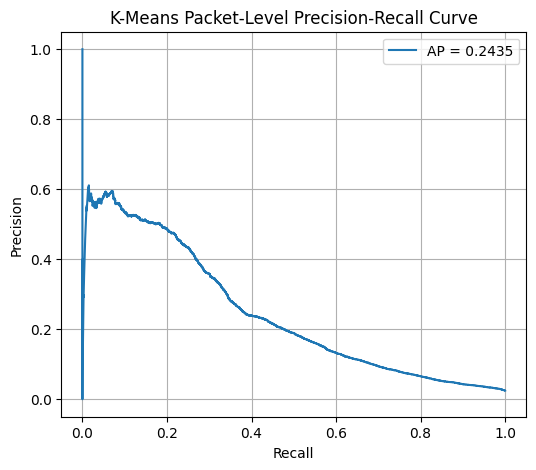

In [217]:
def plot_precision_recall_curve(y_true, scores, title):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    ap = average_precision_score(y_true, scores)
    
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AP = {ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_precision_recall_curve(
    y_true,
    df_result["anomaly_score"].to_numpy(),
    "K-Means Packet-Level Precision-Recall Curve"
)

### PCA cluster visualization

Use PCA to reduce the data to 2 dimensions to show clusters in 2D.

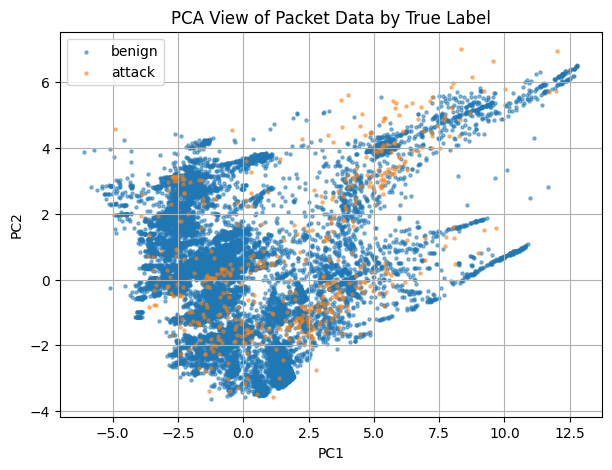

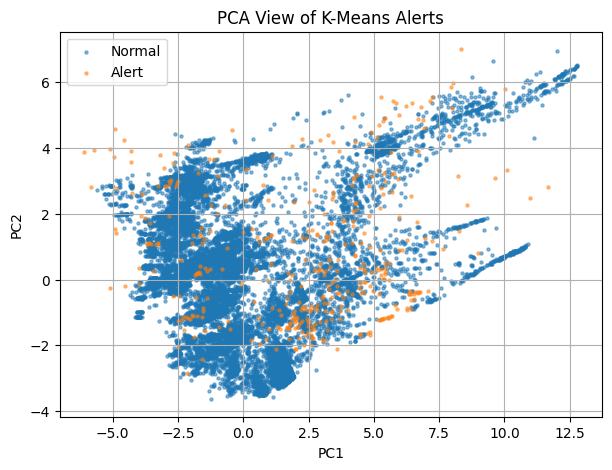

In [218]:
plot_size = min(20000, X.shape[0])
plot_idx = rng.choice(X.shape[0], size=plot_size, replace=False)

pca = PCA(n_components=2, random_state=1)
X_2d = pca.fit_transform(X[plot_idx])

plot_df = pd.DataFrame({
    "PC1": X_2d[:, 0],
    "PC2": X_2d[:, 1],
    "cluster": df_result.iloc[plot_idx]["cluster"].to_numpy(),
    "binary_label": df_result.iloc[plot_idx][BINARY_COL].to_numpy(),
    "y_pred": df_result.iloc[plot_idx]["y_pred"].to_numpy(),
    "attack_type": df_result.iloc[plot_idx][ATTACK_COL].to_numpy()
})

## Plot by true binary label
plt.figure(figsize=(7, 5))

for label in ["benign", "attack"]:
    temp = plot_df[plot_df["binary_label"] == label]
    plt.scatter(temp["PC1"], temp["PC2"], s=5, alpha=0.5, label=label)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA View of Packet Data by True Label")
plt.legend()
plt.grid(True)
plt.show()


## Plot by predicted alert:
plt.figure(figsize=(7, 5))

for label in [0, 1]:
    temp = plot_df[plot_df["y_pred"] == label]
    name = "Normal" if label == 0 else "Alert"
    plt.scatter(temp["PC1"], temp["PC2"], s=5, alpha=0.5, label=name)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA View of K-Means Alerts")
plt.legend()
plt.grid(True)
plt.show()